# FCC Fe no magnético · fonones y termodinámica TDEP
Ejecuta **Run All**. Por defecto procesa todos los NPZ `*_4000K.npz`, incluidos los volúmenes nuevos. Cambia `TEMPERATURE` para otra temperatura. Solo usa archivos directamente en esta carpeta: no vuelve a contar copias en `import_4000K/` ni `a_*/`.

Incluye fonones/DOS por volumen y superpuestos, entropía y Cv vibracionales, residuos de fuerzas como medida de anharmonicidad, corrección cúbica, espectros, energía interna QE, energía libre del modelo TDEP y ajustes BM. Los resultados se guardan en `tdep_results_4000K/` (o la temperatura elegida), con logs y caché por etapa.

Usa una celda primitiva **FCC de un átomo**, cuatro sitios por celda convencional y la ruta FCC elegida por TDEP. El volumen convencional mostrado es **4 × volumen por Fe**. La energía del ajuste es la energía electrónica libre de QE; F_model = U0 + F_vib, sin contribución magnética explícita. La corrección cúbica se muestra aparte.

Se filtran frames incompletos de simulaciones todavía en marcha. La cantidad de frames y temperatura medida se reportan: los puntos con trayectorias cortas son preliminares. Cutoffs y mallas requieren convergencia; no se interpreta un ajuste como prueba de estabilidad. Requiere Python, NumPy, SciPy, pandas, matplotlib, h5py y los ejecutables TDEP.

In [1]:
from pathlib import Path
import os, sys, re, json, hashlib, subprocess, itertools
import numpy as np
import pandas as pd
from scipy.optimize import linear_sum_assignment, curve_fit
import matplotlib.pyplot as plt
from IPython.display import display, Image
import h5py

DATA = Path.cwd().resolve()
if not list(DATA.glob("[0-9]*_*K.npz")):
    DATA = Path("/Users/dajuarez4/Documents/Fe/dataset/fcc/non-mag")
REPO = next(p for p in [DATA,*DATA.parents] if (p/"tdep/build/src").exists())
TDEP = REPO/"tdep/build/src"
TEMPERATURE = 4000           # Cambiar para procesar otra temperatura.
OUT = DATA/f"tdep_results_{TEMPERATURE}K"; OUT.mkdir(exist_ok=True)
SKIP = 0                  # Recorte de la trayectoria unida por volumen.
EVERY = 1
MIN_FRAMES = 10
RC2_REQUESTED, RC3_REQUESTED = 5.0, 3.0
DOS_GRID = [32,32,32]
ANH_GRID = [4,4,4]
SPECTRAL_GRID = [12,12,12]
NQ_PATH, N_ENERGIES = 80, 400
RUN_SPECTRA = True         # Etapa más costosa.
RUN_CUBIC_FREE_ENERGY = True
RECOMPUTE = False
RY_EV, BOHR_A, KB = 13.605693122994, 0.529177210903, 8.617333262145e-5
ENV = os.environ.copy()
ENV.update(OMP_NUM_THREADS="1",OPENBLAS_NUM_THREADS="1",VECLIB_MAXIMUM_THREADS="1")
issues=[]
def save(fig,name):
    for ext in ("png","pdf"):fig.savefig(OUT/(name+"."+ext),dpi=200,bbox_inches="tight")
    plt.close(fig)
def poscar(path,cell,positions):
    lines=["FCC Fe", "1.0", *[" ".join(map(str,v)) for v in cell], "Fe",str(len(positions)),"Direct",
           *[" ".join(map(str,v%1)) for v in positions]]
    path.write_text("\n".join(lines)+"\n")
assert SKIP>=0 and EVERY>=1
sources=sorted([p for p in DATA.glob(f"*_{TEMPERATURE}K.npz")
                if re.fullmatch(r"[0-9.]+_"+str(TEMPERATURE)+r"K\.npz",p.name)],
               key=lambda p:float(p.name.split("_")[0]))
print("Simulaciones FCC:",len(sources),"\nResultados:",OUT)

Simulaciones FCC: 16 
Resultados: /Users/dajuarez4/Documents/Fe/dataset/fcc/non-mag/tdep_results_4000K


## Preparar los inputs FCC y filtrar los registros MD válidos

In [2]:
# Unir reinicios por volumen antes de preparar TDEP.
FRAME_KEYS = ["positions","positions_unit","forces_ry_au","cell_parameters","cell_parameters_unit",
              "iteration","time_ps","energy_ry","internal_energy_ry","ekin_ry","temperature_K",
              "pressure_GPa","pressure_kbar","frame_valid","force_frame_valid","position_frame_valid",
              "mag_total_Bohr","mag_total_vector_Bohr","abs_mag_total_Bohr","abs_mag_per_atom_Bohr",
              "local_magnetization_Bohr","local_magnetization_frame_valid"]
def natural_key(path):
    return [int(x) if x.isdigit() else x.lower() for x in re.split(r"(\d+)",str(path))]
def merge_segments(paths):
    merged=None;provenance=[];hashes=[]
    for path in sorted(paths,key=natural_key):
        with np.load(path,allow_pickle=False) as archive: part=dict(archive)
        hashes.append(hashlib.sha256(path.read_bytes()).hexdigest())
        nf=len(part["positions"]);drop=0;offset=0.0
        if merged is not None:
            if not np.array_equal(part["symbols"],merged["symbols"]):raise ValueError("Orden de especies distinto entre reinicios")
            if str(part["input_cell_unit"])!=str(merged["input_cell_unit"]) or not np.allclose(part["input_cell_parameters"],merged["input_cell_parameters"],rtol=1e-6,atol=1e-6):
                raise ValueError("Celda distinta entre reinicios")
            # Largest exact tail/prefix match: retain one copy, no approximate deduplication.
            for size in range(min(len(merged["positions"]),nf),0,-1):
                if not np.array_equal(merged["positions_unit"][-size:],part["positions_unit"][:size]):continue
                delta=np.asarray(merged["positions"][-size:],float)-part["positions"][:size]
                if np.all(part["positions_unit"][:size]=="crystal"):delta-=np.rint(delta)
                if np.isfinite(delta).all() and np.max(np.abs(delta))<1e-7:
                    drop=size;break
            if drop<nf:
                previous=np.asarray(merged["time_ps"],float)
                previous=previous[np.isfinite(previous)]
                incoming=np.asarray(part["time_ps"],float)
                if len(previous) and np.isfinite(incoming[drop]) and incoming[drop]<=previous[-1]:
                    if drop==0 and incoming[0]>previous[0]+1e-6:
                        raise ValueError("Reinicio con tiempos solapados y posiciones diferentes; revisar manualmente")
                    dt=np.diff(incoming);dt=dt[np.isfinite(dt)&(dt>0)]
                    if not len(dt):raise ValueError("No se puede reconstruir el tiempo del reinicio")
                    offset=float(previous[-1]+np.median(dt)-incoming[drop])
        provenance.append(dict(source=str(path),raw_frames=nf,overlap_removed=drop,time_offset_ps=offset))
        part["time_ps"]=np.asarray(part["time_ps"],dtype=float)+offset
        if merged is None:
            merged=part.copy()
            merged["segment_source"]=np.full(nf,str(path),dtype="U1024")
            merged["segment_frame_index"]=np.arange(nf)
        else:
            for key in FRAME_KEYS:
                if key in merged and key in part:merged[key]=np.concatenate([merged[key],part[key][drop:]],axis=0)
                elif key in merged or key in part:raise ValueError("Campo inconsistente entre segmentos: "+key)
            merged["segment_source"]=np.concatenate([merged["segment_source"],np.full(nf-drop,str(path),dtype="U1024")])
            merged["segment_frame_index"]=np.concatenate([merged["segment_frame_index"],np.arange(drop,nf)])
    return merged,provenance,hashes

groups={}
for path in sources:
    case=DATA/("a_"+path.name.split("_")[0])
    groups.setdefault(case,[]).append(path)

prepared=[]
for source,segment_paths in sorted(groups.items(),key=lambda item:natural_key(item[0])):
    try:
        d,segment_report,source_hashes=merge_segments(segment_paths)
        cell=np.asarray(d["input_cell_parameters"],float)
        unit=str(d["input_cell_unit"]).lower()
        if unit=="bohr":cell*=BOHR_A
        elif unit!="angstrom":raise ValueError("Unidad de celda no soportada: "+unit)
        nat=len(d["symbols"])
        # QE magnetic labels Fe01...Fe32 are all elemental iron for TDEP.
        labels=[x.decode() if isinstance(x,bytes) else str(x) for x in d["symbols"]]
        if not all(re.fullmatch(r"Fe(?:[0-9]+)?",label.strip()) for label in labels):
            raise ValueError("Especies distintas de Fe: "+repr(sorted(set(labels))))
        if not np.allclose(cell,np.diag(np.diag(cell))):
            raise ValueError("Se espera una supercelda FCC ortogonal")
        v=abs(np.linalg.det(cell))/nat;a=(4*v)**(1/3)
        repeat=np.rint(np.diag(cell)/a).astype(int)
        if np.any(repeat<1) or np.prod(repeat)*4!=nat or not np.allclose(np.diag(cell)/repeat,a,rtol=1e-5):
            raise ValueError("No se pudo inferir la supercelda FCC")
        ideal=np.array([(np.array(ijk)+basis)/repeat for ijk in itertools.product(*[range(k) for k in repeat])
                        for basis in [np.array([0.,0.,0.]),np.array([0.,.5,.5]),np.array([.5,0.,.5]),np.array([.5,.5,0.]) ]])
        initial=d["initial_positions_alat"]@np.linalg.inv(d["initial_cell_alat"])
        delta=initial[:,None,:]-ideal[None,:,:];delta-=np.rint(delta)
        ri,ci=linear_sum_assignment(np.sum((delta@cell)**2,axis=2))
        ordered=np.empty_like(ideal);ordered[ri]=ideal[ci]
        max_assignment=float(np.linalg.norm((delta@cell)[ri,ci],axis=1).max())
        if max_assignment>.35*a:raise ValueError("Asignación a sitios FCC ambigua; revisar referencia ideal")
        mask=np.isfinite(d["positions"]).all(axis=(1,2)) & np.isfinite(d["forces_ry_au"]).all(axis=(1,2))
        for key in ["energy_ry","ekin_ry","temperature_K","pressure_GPa","time_ps"]:mask &= np.isfinite(d[key])
        if "frame_valid" in d:mask &= d["frame_valid"]
        selected=np.arange(len(mask))[SKIP::EVERY];selected=selected[mask[selected]]
        if len(selected)<MIN_FRAMES:raise ValueError("Muy pocos frames válidos: "+str(len(selected)))
        positions=np.asarray(d["positions"],float)[selected]
        units=set(map(str,d["positions_unit"][selected]))
        if units=={"angstrom"}:positions=positions@np.linalg.inv(cell)
        elif units!={"crystal"}:raise ValueError("Unidades de posiciones no soportadas")
        # Older fixed-volume archives omit per-frame cells (all NaN / None).
        # Use the input cell only when the initial output cell agrees with it.
        meta=json.loads(str(d["metadata_json"]))
        initial_cell=np.asarray(d["initial_cell_alat"])*float(meta["alat_bohr"])*BOHR_A
        if not np.allclose(initial_cell,cell,rtol=2e-4,atol=2e-4):
            raise ValueError("La celda inicial no coincide con la celda de entrada")
        # Reject any recorded change in cell.
        for c,u in zip(d["cell_parameters"][selected],d["cell_parameters_unit"][selected]):
            if str(u).lower() in {"none","","nan"} and np.isnan(c).all():
                continue
            factor={"angstrom":1.,"bohr":BOHR_A,"alat":float(json.loads(str(d["metadata_json"]))["alat_bohr"])*BOHR_A}.get(str(u))
            if factor is None or not np.allclose(c*factor,cell,rtol=2e-4,atol=2e-4):raise ValueError("Celda variable o unidad no soportada")
        name=source.name
        work=OUT/"calculations"/name;work.mkdir(parents=True,exist_ok=True)
        primitive=a/2*np.array([[0,1,1],[1,0,1],[1,1,0]])
        poscar(work/"infile.ucposcar",primitive,np.zeros((1,3)))
        poscar(work/"infile.ssposcar",cell,ordered)
        np.savetxt(work/"infile.positions",positions.reshape(-1,3),fmt="%.16e")
        np.savetxt(work/"infile.forces",(d["forces_ry_au"][selected]*RY_EV/BOHR_A).reshape(-1,3),fmt="%.16e")
        dt=float(np.nanmedian(np.diff(d["time_ps"]))*1000)
        if not np.isfinite(dt) or dt<=0:raise ValueError("No hay paso temporal válido")
        epot=d["energy_ry"][selected]*RY_EV;ekin=d["ekin_ry"][selected]*RY_EV
        stat=np.zeros((len(selected),13));stat[:,0]=np.arange(1,len(selected)+1)
        stat[:,1]=d["time_ps"][selected]*1000;stat[:,2]=epot+ekin;stat[:,3]=epot;stat[:,4]=ekin
        stat[:,5]=d["temperature_K"][selected];stat[:,6]=d["pressure_GPa"][selected]
        np.savetxt(work/"infile.stat",stat,fmt=["%d"]+["%.12e"]*12)
        (work/"infile.meta").write_text(f"{nat}\n{len(selected)}\n{dt}\n{TEMPERATURE}\n")
        cutoff=.49*min(np.linalg.norm(cell,axis=1))
        config=dict(source_sha256=source_hashes,segment_sources=[str(x) for x in sorted(segment_paths,key=natural_key)],temperature=TEMPERATURE,
                    skip=SKIP,every=EVERY,rc2=min(RC2_REQUESTED,cutoff),rc3=min(RC3_REQUESTED,cutoff),
                    dos_grid=DOS_GRID,anh_grid=ANH_GRID,spectral_grid=SPECTRAL_GRID,nq=NQ_PATH,ne=N_ENERGIES,
                    energy="QE electronic free energy",version=3)
        fingerprint=hashlib.sha256(json.dumps(config,sort_keys=True).encode()).hexdigest()
        (work/"settings.json").write_text(json.dumps(config,indent=2))
        clean={key:(value[selected] if key in FRAME_KEYS+["segment_source","segment_frame_index"] else value) for key,value in d.items()}
        clean["metadata_json"]=np.asarray(json.dumps(dict(natoms=nat,nsteps=len(selected),segments=segment_report)))
        np.savez_compressed(work/"merged_valid_trajectory.npz",**clean)
        (work/"segments.json").write_text(json.dumps(segment_report,indent=2))
        pd.DataFrame(dict(source=d["segment_source"][selected],source_frame=d["segment_frame_index"][selected],time_ps=d["time_ps"][selected],original_iteration=d["iteration"][selected])).to_csv(work/"frame_provenance.csv",index=False)
        row=dict(source=str(source),segments=len(segment_paths),work=str(work),a_A=a,V_Fe_A3=v,V_conv_A3=4*v,natoms=nat,
                 frames=len(selected),mean_T_K=float(np.mean(stat[:,5])),pressure_GPa=float(np.mean(stat[:,6])),
                 U_QE_eV_Fe=float(np.nanmean(d["internal_energy_ry"][selected])*RY_EV/nat),
                 absolute_magnetization_Bohr_Fe=float(np.nanmean(d["abs_mag_total_Bohr"][selected])/nat) if "abs_mag_total_Bohr" in d and np.isfinite(d["abs_mag_total_Bohr"][selected]).any() else np.nan,
                 max_assignment_A=max_assignment,fingerprint=fingerprint,config=config)
        prepared.append(row)
    except (ValueError,KeyError,OSError) as exc:issues.append(dict(source=str(source),error=str(exc)))
display(pd.DataFrame([{k:v for k,v in r.items() if k not in ["config","fingerprint"]} for r in prepared]))
display(pd.DataFrame(issues))
pd.DataFrame(issues).to_csv(OUT/"preparation_issues.csv",index=False)
if not prepared:
    details="\n".join(Path(r["source"]).name+": "+r["error"] for r in issues)
    raise RuntimeError("No hay segmentos preparados.\n"+(details or "No se encontraron NPZ; revisar DATA."))

,source,segments,work,a_A,V_Fe_A3,V_conv_A3,natoms,frames,mean_T_K,pressure_GPa,U_QE_eV_Fe,absolute_magnetization_Bohr_Fe,max_assignment_A
0,/Users/dajuarez4/Documents/Fe/dataset/fcc/non-...,1,/Users/dajuarez4/Documents/Fe/dataset/fcc/non-...,2.85,5.787281,23.149123,128,399,3764.264257,599.641606,-4474.263480,NaN,0.0
1,/Users/dajuarez4/Documents/Fe/dataset/fcc/non-...,1,/Users/dajuarez4/Documents/Fe/dataset/fcc/non-...,2.90,6.097251,24.389002,128,399,3657.673102,490.047184,-4475.291228,NaN,0.0
2,/Users/dajuarez4/Documents/Fe/dataset/fcc/non-...,1,/Users/dajuarez4/Documents/Fe/dataset/fcc/non-...,2.95,6.418094,25.672376,128,399,3607.074084,398.502119,-4476.155747,NaN,0.0
3,/Users/dajuarez4/Documents/Fe/dataset/fcc/non-...,1,/Users/dajuarez4/Documents/Fe/dataset/fcc/non-...,3.00,6.750000,27.000000,128,399,3652.434926,322.841841,-4476.859657,NaN,0.0
4,/Users/dajuarez4/Documents/Fe/dataset/fcc/non-...,1,/Users/dajuarez4/Documents/Fe/dataset/fcc/non-...,3.05,7.093156,28.372624,128,399,3630.444668,259.448326,-4477.441223,NaN,0.0
5,/Users/dajuarez4/Documents/Fe/dataset/fcc/non-...,1,/Users/dajuarez4/Documents/Fe/dataset/fcc/non-...,3.10,7.447749,29.790997,128,399,3640.824147,206.921549,-4477.912646,NaN,0.0
6,/Users/dajuarez4/Documents/Fe/dataset/fcc/non-...,1,/Users/dajuarez4/Documents/Fe/dataset/fcc/non-...,3.15,7.813969,31.255878,128,399,3778.949714,164.235788,-4478.266896,NaN,0.0
7,/Users/dajuarez4/Documents/Fe/dataset/fcc/non-...,1,/Users/dajuarez4/Documents/Fe/dataset/fcc/non-...,3.20,8.192000,32.768001,128,399,3751.484745,127.994268,-4478.558266,NaN,0.0
8,/Users/dajuarez4/Documents/Fe/dataset/fcc/non-...,1,/Users/dajuarez4/Documents/Fe/dataset/fcc/non-...,3.25,8.582031,34.328125,128,296,3614.477265,97.823593,-4478.771314,NaN,0.0
9,/Users/dajuarez4/Documents/Fe/dataset/fcc/non-...,1,/Users/dajuarez4/Documents/Fe/dataset/fcc/non-...,3.30,8.984250,35.936998,128,216,3366.708950,72.800622,-4478.941609,NaN,0.0


""


## Ejecutar TDEP (reanudable; logs por etapa)
Los resultados cambian si se modifica el muestreo o los parámetros. La huella de inputs invalida automáticamente las etapas anteriores. Fallos/estructuras inestables quedan registrados; no se sustituyen valores por cero.

In [3]:
def run_stage(row,stage,exe,arguments,expected):
    work=Path(row["work"]);marker=work/(stage+".done.json")
    if not RECOMPUTE and marker.exists():
        record=json.loads(marker.read_text())
        if record.get("fingerprint")==row["fingerprint"] and all((work/f).exists() for f in expected):return True
    for filename in expected:
        p=work/filename
        if p.exists():p.unlink()
    cmd=[str(TDEP/exe/exe),*map(str,arguments)]
    with (work/(stage+".log")).open("w") as log:
        result=subprocess.run(cmd,cwd=work,env=ENV,stdout=log,stderr=subprocess.STDOUT)
    text=(work/(stage+".log")).read_text(errors="replace")
    ok=result.returncode==0 and all((work/f).exists() for f in expected) and "Stopping prematurely" not in text
    if ok:marker.write_text(json.dumps(dict(fingerprint=row["fingerprint"],command=cmd),indent=2))
    else:
        if marker.exists():marker.unlink()
        issues.append(dict(source=row["source"],error=stage+" failed; see "+str(work/(stage+".log"))))
    print(Path(row["source"]).name,round(row["a_A"],3),stage,"OK" if ok else "FAILED",flush=True)
    return ok
for row in prepared:
    work=Path(row["work"]);c=row["config"]
    if not run_stage(row,"fit","extract_forceconstants",["-rc2",c["rc2"],"-rc3",c["rc3"]],
                     ["outfile.forceconstant","outfile.forceconstant_thirdorder","outfile.U0"]):continue
    for suffix in ["","_thirdorder"]:
        p=work/("infile.forceconstant"+suffix)
        if p.is_symlink() or p.exists():p.unlink()
        p.symlink_to("outfile.forceconstant"+suffix)
    run_stage(row,"phonons","phonon_dispersion_relations",["--dos","--qpoint_grid",*DOS_GRID,"--temperature",TEMPERATURE],
              ["outfile.free_energy","outfile.dispersion_relations","outfile.phonon_dos"])
    if RUN_CUBIC_FREE_ENERGY:
        run_stage(row,"anharmonic","anharmonic_free_energy",["--thirdorder","--qpoint_grid",*ANH_GRID],["outfile.anharmonic_free_energy"])
    if RUN_SPECTRA:
        run_stage(row,"spectral","lineshape",["--path","--temperature",TEMPERATURE,"--unit","mev",
                  "--qpoint_grid",*SPECTRAL_GRID,"--nq_on_path",NQ_PATH,"--n_energies",N_ENERGIES],
                  ["outfile.phonon_spectral_function.hdf5"])
pd.DataFrame(issues).to_csv(OUT/"issues.csv",index=False)

a_2.85 2.85 fit OK
a_2.85 2.85 phonons OK
a_2.85 2.85 anharmonic OK
a_2.85 2.85 spectral OK
a_2.90 2.9 fit OK
a_2.90 2.9 phonons OK
a_2.90 2.9 anharmonic OK
a_2.90 2.9 spectral OK
a_2.95 2.95 fit OK
a_2.95 2.95 phonons OK
a_2.95 2.95 anharmonic OK
a_2.95 2.95 spectral OK
a_3.00 3.0 fit OK
a_3.00 3.0 phonons OK
a_3.00 3.0 anharmonic OK
a_3.00 3.0 spectral OK
a_3.05 3.05 fit OK
a_3.05 3.05 phonons OK
a_3.05 3.05 anharmonic OK
a_3.05 3.05 spectral OK
a_3.10 3.1 fit OK
a_3.10 3.1 phonons OK
a_3.10 3.1 anharmonic OK
a_3.10 3.1 spectral OK
a_3.15 3.15 fit OK
a_3.15 3.15 phonons OK
a_3.15 3.15 anharmonic OK
a_3.15 3.15 spectral OK
a_3.20 3.2 fit OK
a_3.20 3.2 phonons OK
a_3.20 3.2 anharmonic OK
a_3.20 3.2 spectral OK
a_3.25 3.25 fit OK
a_3.25 3.25 phonons OK
a_3.25 3.25 anharmonic OK
a_3.25 3.25 spectral OK
a_3.30 3.3 fit OK
a_3.30 3.3 phonons OK
a_3.30 3.3 anharmonic OK
a_3.30 3.3 spectral OK
a_3.35 3.35 fit OK
a_3.35 3.35 phonons OK
a_3.35 3.35 anharmonic OK
a_3.35 3.35 spectral OK
a_3.40 3

## Propiedades, fonones y espectros por volumen

In [4]:
results=[]
def current(row,stage):
    p=Path(row["work"])/(stage+".done.json")
    return p.exists() and json.loads(p.read_text()).get("fingerprint")==row["fingerprint"]
for row in prepared:
    work=Path(row["work"]);r={k:v for k,v in row.items() if k not in ["config","fingerprint"]}
    tag=work.name
    if current(row,"fit"):
        text=(work/"fit.log").read_text()
        for order,key in [("second","sigma2"),("third","sigma23")]:
            matches=re.findall(r"^\s*"+order+r" order:\s+([-+0-9.Ee]+)\s+([-+0-9.Ee]+)\s+([-+0-9.Ee]+)\s+([-+0-9.Ee]+)\s+([-+0-9.Ee]+)",text,re.M)
            if matches:r[key]=float(matches[-1][-1])
    if current(row,"phonons"):
        values=np.loadtxt(work/"outfile.free_energy",ndmin=2)[0]
        if np.isfinite(values).all() and abs(values[1])<1e6:
            u0=np.loadtxt(work/"outfile.U0",ndmin=2)[0,1]
            r.update(F_eV_Fe=u0+values[1],S_vib_kB_Fe=values[2]/KB,Cv_vib_kB_Fe=values[3]/KB)
        else:issues.append(dict(source=row["source"],error="Invalid phonon free energy / unstable modes"))
        disp=np.loadtxt(work/"outfile.dispersion_relations");dos=np.loadtxt(work/"outfile.phonon_dos")
        r["min_frequency_THz"]=float(disp[:,1:].min())
        ticks=re.findall(r'"([^"\n]+)"\s+([0-9.eE+-]+)',(work/"outfile.dispersion_relations.gnuplot").read_text())
        fig,(ax,bx)=plt.subplots(1,2,figsize=(10,4),gridspec_kw={"width_ratios":[3,1]},sharey=True,layout="constrained")
        ax.plot(disp[:,0],disp[:,1:],lw=1);bx.plot(dos[:,1],dos[:,0])
        if ticks:ax.set_xticks([float(x[1]) for x in ticks],[x[0] for x in ticks])
        ax.set(ylabel="Frequency (THz)",title=f'a={row["a_A"]:.2f} Å · {row["frames"]} frames');bx.set_xlabel("DOS")
        ax.axhline(0,color="gray",lw=.5);ax.grid(alpha=.2);save(fig,"phonons__"+tag)
    if current(row,"anharmonic"):
        m=re.search(r"^\s*F_3\s*=\s*([-+0-9.Ee]+)",(work/"anharmonic.log").read_text(),re.M)
        if m:r["F3_meV_Fe"]=float(m[1])*1000
    if current(row,"spectral"):
        with h5py.File(work/"outfile.phonon_spectral_function.hdf5") as f:
            q=f["q_values"][:];e=f["energy_values"][:];s=f["spectral_function"][:];qt=f["q_ticks"][:]
            labels=f.attrs["q_tick_labels"];labels=labels.decode() if isinstance(labels,bytes) else str(labels)
        if np.isfinite(s).all() and s.max()>0:
            fig,ax=plt.subplots(figsize=(8,4),layout="constrained")
            mesh=ax.pcolormesh(q,e,np.log10(np.maximum(s/s.max(),1e-4)),cmap="Blues",vmin=-4,vmax=0,shading="auto",rasterized=True)
            ax.set_xticks(qt,["Γ" if x in ("G","GM") else x for x in labels.split()])
            ax.set(ylabel="Energy (meV)",title=f'FCC Fe noncollinear · {TEMPERATURE} K · a={row["a_A"]:.2f} Å')
            fig.colorbar(mesh,ax=ax,label="log₁₀ normalized spectral intensity")
            save(fig,"spectral__"+tag)
    results.append(r)
results=pd.DataFrame(results)
results.to_csv(OUT/"all_volumes.csv",index=False)
pd.DataFrame(issues).to_csv(OUT/"issues.csv",index=False)
display(results)

,source,segments,work,a_A,V_Fe_A3,V_conv_A3,natoms,frames,mean_T_K,pressure_GPa,U_QE_eV_Fe,absolute_magnetization_Bohr_Fe,max_assignment_A,sigma2,sigma23,F_eV_Fe,S_vib_kB_Fe,Cv_vib_kB_Fe,min_frequency_THz,F3_meV_Fe
0,/Users/dajuarez4/Documents/Fe/dataset/fcc/non-...,1,/Users/dajuarez4/Documents/Fe/dataset/fcc/non-...,2.85,5.787281,23.149123,128,399,3764.264257,599.641606,-4474.263480,NaN,0.0,0.262843,0.140006,-4476.512470,8.163054,2.990093,0.0,-5.0607
1,/Users/dajuarez4/Documents/Fe/dataset/fcc/non-...,1,/Users/dajuarez4/Documents/Fe/dataset/fcc/non-...,2.90,6.097251,24.389002,128,399,3657.673102,490.047184,-4475.291228,NaN,0.0,0.289882,0.148844,-4477.606963,8.389876,2.991513,0.0,-5.7541
2,/Users/dajuarez4/Documents/Fe/dataset/fcc/non-...,1,/Users/dajuarez4/Documents/Fe/dataset/fcc/non-...,2.95,6.418094,25.672376,128,399,3607.074084,398.502119,-4476.155747,NaN,0.0,0.289706,0.151478,-4478.524772,8.572141,2.992493,0.0,-6.2557
3,/Users/dajuarez4/Documents/Fe/dataset/fcc/non-...,1,/Users/dajuarez4/Documents/Fe/dataset/fcc/non-...,3.00,6.750000,27.000000,128,399,3652.434926,322.841841,-4476.859657,NaN,0.0,0.303821,0.165303,-4479.318089,8.812595,2.993618,0.0,-6.7712
4,/Users/dajuarez4/Documents/Fe/dataset/fcc/non-...,1,/Users/dajuarez4/Documents/Fe/dataset/fcc/non-...,3.05,7.093156,28.372624,128,399,3630.444668,259.448326,-4477.441223,NaN,0.0,0.333423,0.186125,-4479.973056,9.030340,2.994444,0.0,-7.9231
5,/Users/dajuarez4/Documents/Fe/dataset/fcc/non-...,1,/Users/dajuarez4/Documents/Fe/dataset/fcc/non-...,3.10,7.447749,29.790997,128,399,3640.824147,206.921549,-4477.912646,NaN,0.0,0.357984,0.200185,-4480.538265,9.289662,2.995317,0.0,-8.8814
6,/Users/dajuarez4/Documents/Fe/dataset/fcc/non-...,1,/Users/dajuarez4/Documents/Fe/dataset/fcc/non-...,3.15,7.813969,31.255878,128,399,3778.949714,164.235788,-4478.266896,NaN,0.0,0.385933,0.232772,-4481.006113,9.561912,2.996047,0.0,-9.5413
7,/Users/dajuarez4/Documents/Fe/dataset/fcc/non-...,1,/Users/dajuarez4/Documents/Fe/dataset/fcc/non-...,3.20,8.192000,32.768001,128,399,3751.484745,127.994268,-4478.558266,NaN,0.0,0.426745,0.261204,-4481.392576,9.838972,2.996713,0.0,-11.3883
8,/Users/dajuarez4/Documents/Fe/dataset/fcc/non-...,1,/Users/dajuarez4/Documents/Fe/dataset/fcc/non-...,3.25,8.582031,34.328125,128,296,3614.477265,97.823593,-4478.771314,NaN,0.0,0.494494,0.323754,-4481.714361,10.202746,2.997315,0.0,-13.4329
9,/Users/dajuarez4/Documents/Fe/dataset/fcc/non-...,1,/Users/dajuarez4/Documents/Fe/dataset/fcc/non-...,3.30,8.984250,35.936998,128,216,3366.708950,72.800622,-4478.941609,NaN,0.0,0.576404,0.417266,-4482.019218,10.676197,2.997976,0.0,-15.7283


## Propiedades vs volumen y ajuste Birch–Murnaghan
Cada punto utiliza todos los frames válidos de la trayectoria unida de ese volumen. Los reinicios se documentan en `segments.json` y `frame_provenance.csv`. El ajuste BM con cinco volúmenes y cuatro parámetros es descriptivo; se señala si el mínimo está fuera del rango muestreado. No se añade entropía de espín.

,quantity,E0_eV_Fe,V0_A3_Fe,B0_GPa,B0_prime,RMSE_meV_Fe,V0_in_range
0,F_eV_Fe,-4482.596795,11.439126,239.638420,3.835542,29.969677,True
1,U_QE_eV_Fe,-4479.278373,11.538872,103.183272,6.611508,31.475283,True


Resultados: /Users/dajuarez4/Documents/Fe/dataset/fcc/non-mag/tdep_results_4000K


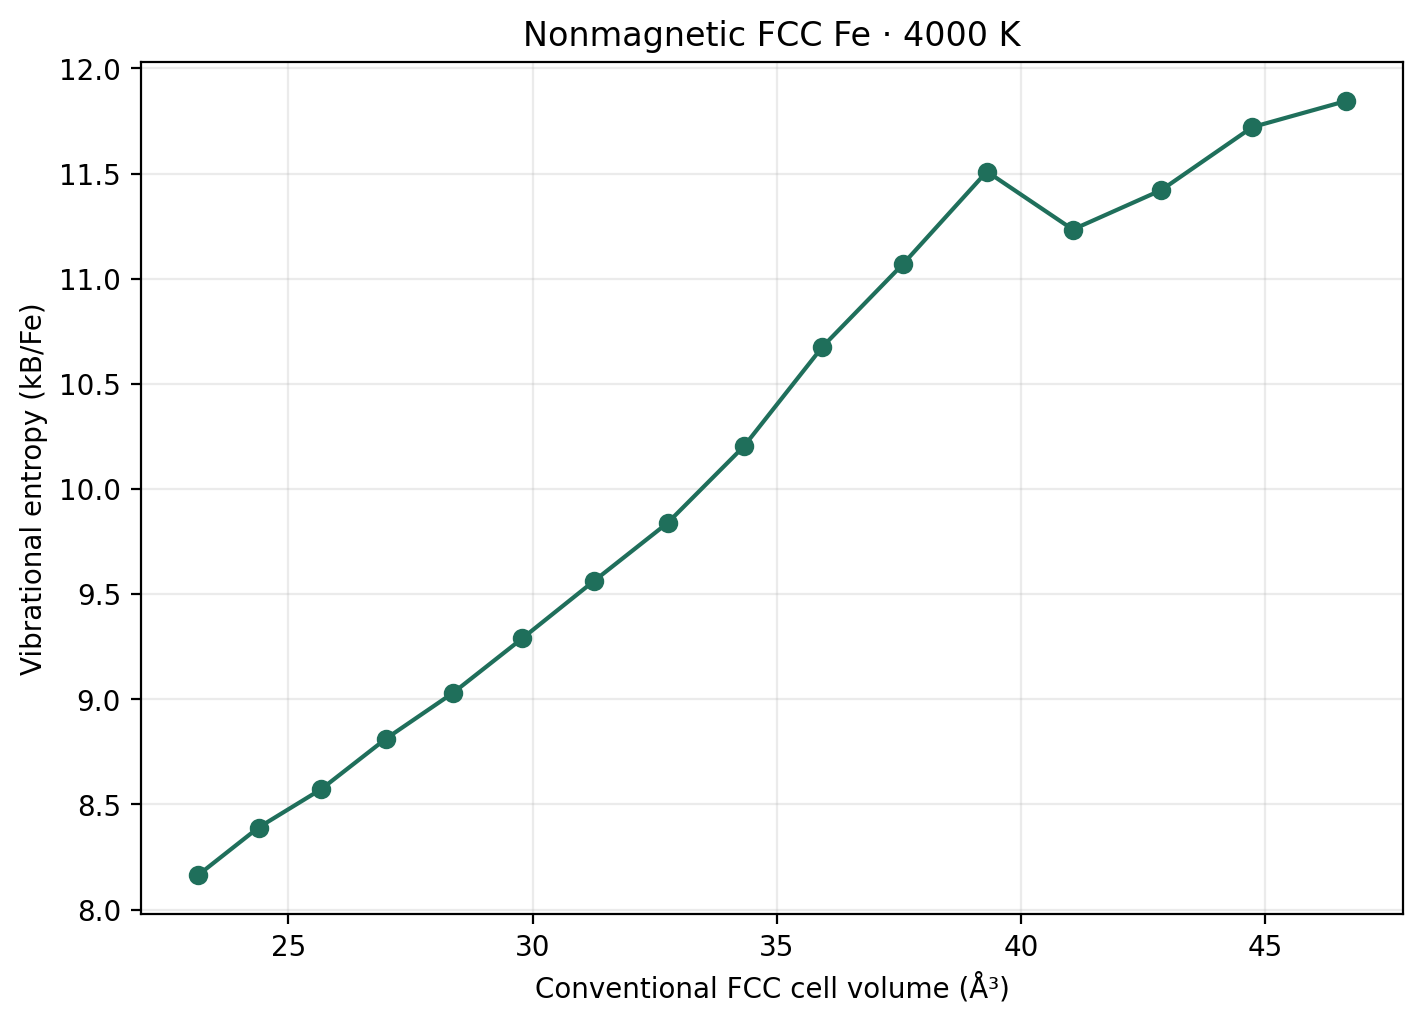

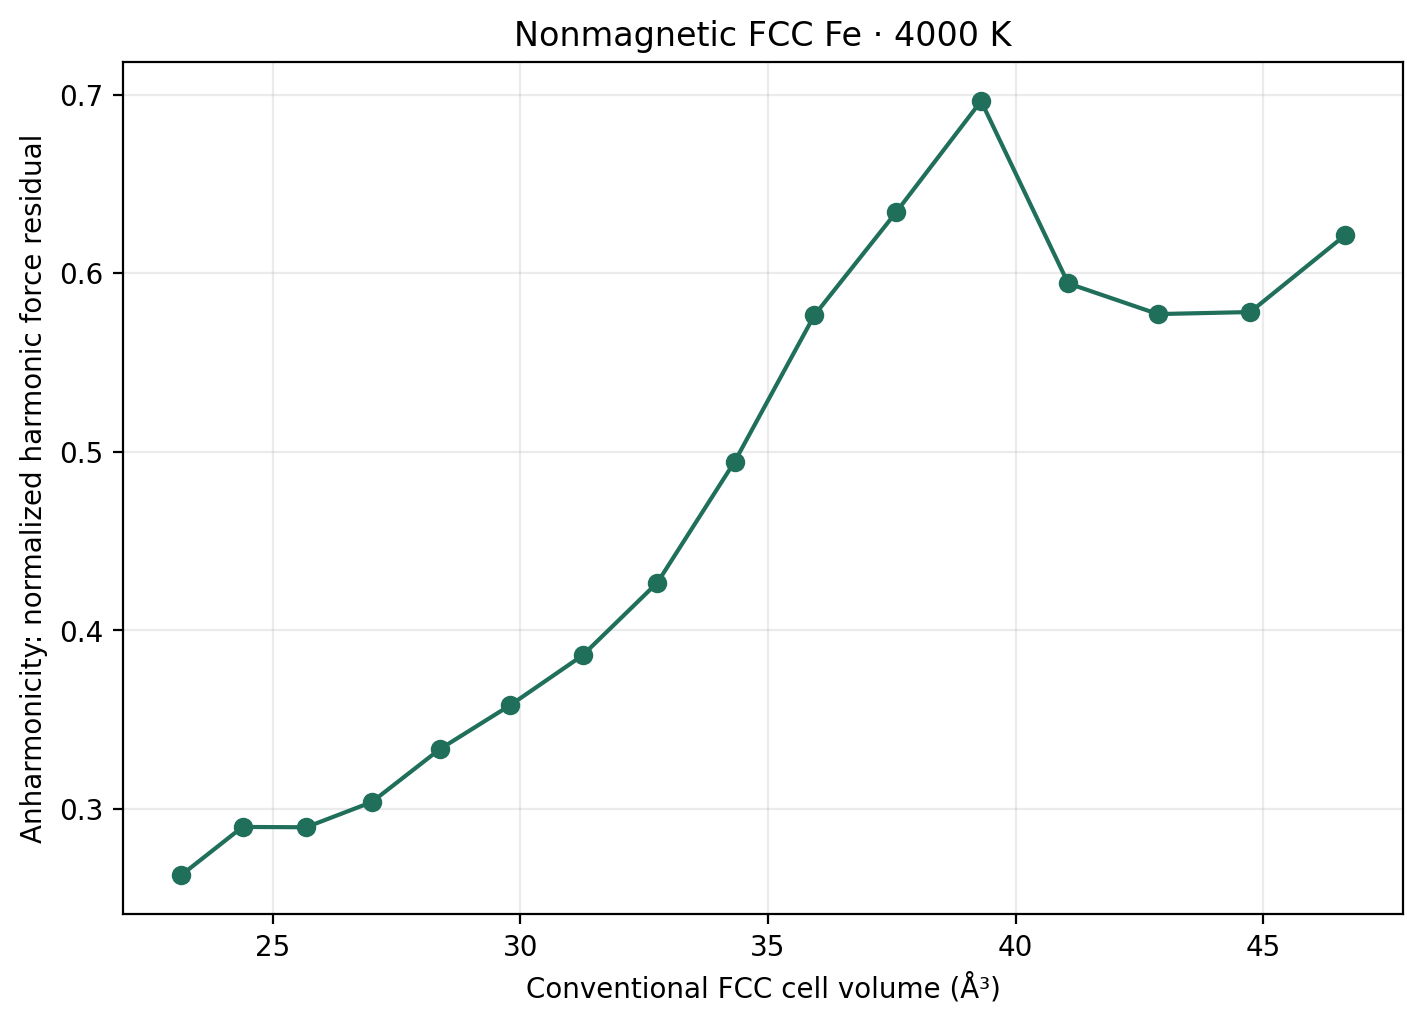

In [5]:
results["volume_key"]=results.V_Fe_A3.round(5)
assert results.volume_key.is_unique, "Más de un caso para el mismo volumen; revisar carpetas"
selected=results.sort_values("V_Fe_A3").copy()
selected.to_csv(OUT/"selected_volume_series.csv",index=False)
for key,label in [("F_eV_Fe","TDEP F_el + F_vib (eV/Fe)"),("U_QE_eV_Fe","QE internal energy (eV/Fe)"),
    ("S_vib_kB_Fe","Vibrational entropy (kB/Fe)"),("Cv_vib_kB_Fe","Vibrational Cv (kB/Fe)"),
    ("sigma2","Anharmonicity: normalized harmonic force residual"),("sigma23","Residual with third-order forces"),
    ("F3_meV_Fe","Cubic free-energy correction (meV/Fe)"),("pressure_GPa","Mean QE pressure (GPa)"),
    ("absolute_magnetization_Bohr_Fe","Absolute magnetization (μB/Fe)")]:
    if key not in selected:continue
    good=selected[np.isfinite(selected[key])]
    fig,ax=plt.subplots(figsize=(7,5),layout="constrained")
    ax.plot(good.V_conv_A3,good[key],"o-",color="#1f6f5b")
    ax.set(xlabel="Conventional FCC cell volume (Å³)",ylabel=label,title=f"Nonmagnetic FCC Fe · {TEMPERATURE} K")
    ax.ticklabel_format(axis="y",style="plain",useOffset=False);ax.grid(alpha=.25);save(fig,key+"_vs_volume")
def bm(v,e0,v0,b,bp):
    eta=(v0/v)**(2/3);s=eta-1
    return e0+9*v0*b/16*(bp*s**3+s*s*(6-4*eta))
fits=[]
for key in ["F_eV_Fe","U_QE_eV_Fe"]:
    if key not in selected:continue
    g=selected[np.isfinite(selected[key])]
    if len(g)<5:print("BM skipped:",key,"requires >=5 valid volumes");continue
    v=g.V_Fe_A3.to_numpy();y=g[key].to_numpy();ref=y.min()
    try:
        p,_=curve_fit(bm,v,y-ref,p0=[0,v.max(),1,4],bounds=([-20,.8*v.min(),1e-6,-5],[20,5*v.max(),20,20]),maxfev=50000)
        fits.append(dict(quantity=key,E0_eV_Fe=p[0]+ref,V0_A3_Fe=p[1],B0_GPa=p[2]*160.21766208,B0_prime=p[3],
                         RMSE_meV_Fe=float(np.sqrt(np.mean((bm(v,*p)-(y-ref))**2))*1000),V0_in_range=bool(v.min()<=p[1]<=v.max())))
        grid=np.linspace(v.min(),v.max(),300)
        fig,ax=plt.subplots(figsize=(7,5),layout="constrained")
        ax.scatter(4*v,(y-ref-p[0])*1000,color="#1f6f5b")
        ax.plot(4*grid,(bm(grid,*p)-p[0])*1000,color="#c24b2a",label="BM fit")
        ax.set(xlabel="Conventional FCC cell volume (Å³)",ylabel="Relative energy (meV/Fe)",title=key)
        ax.legend();ax.grid(alpha=.25);save(fig,"BM_relative_"+key)
    except (RuntimeError,ValueError) as exc:print("BM failed:",key,exc)
pd.DataFrame(fits).to_csv(OUT/"BM_fits.csv",index=False)
display(pd.DataFrame(fits))
print("Resultados:",OUT)
for key in ["S_vib_kB_Fe","sigma2"]:
    p=OUT/(key+"_vs_volume.png")
    if p.exists():display(Image(filename=str(p),width=750))

## Fonones de todos los volúmenes juntos
Superpone las dispersiones y DOS de las trayectorias unidas por volumen. Se alinea la ruta de simetría entre celdas de distintos tamaños. Esta celda puede ejecutarse sola cuando ya existen los outputs TDEP.

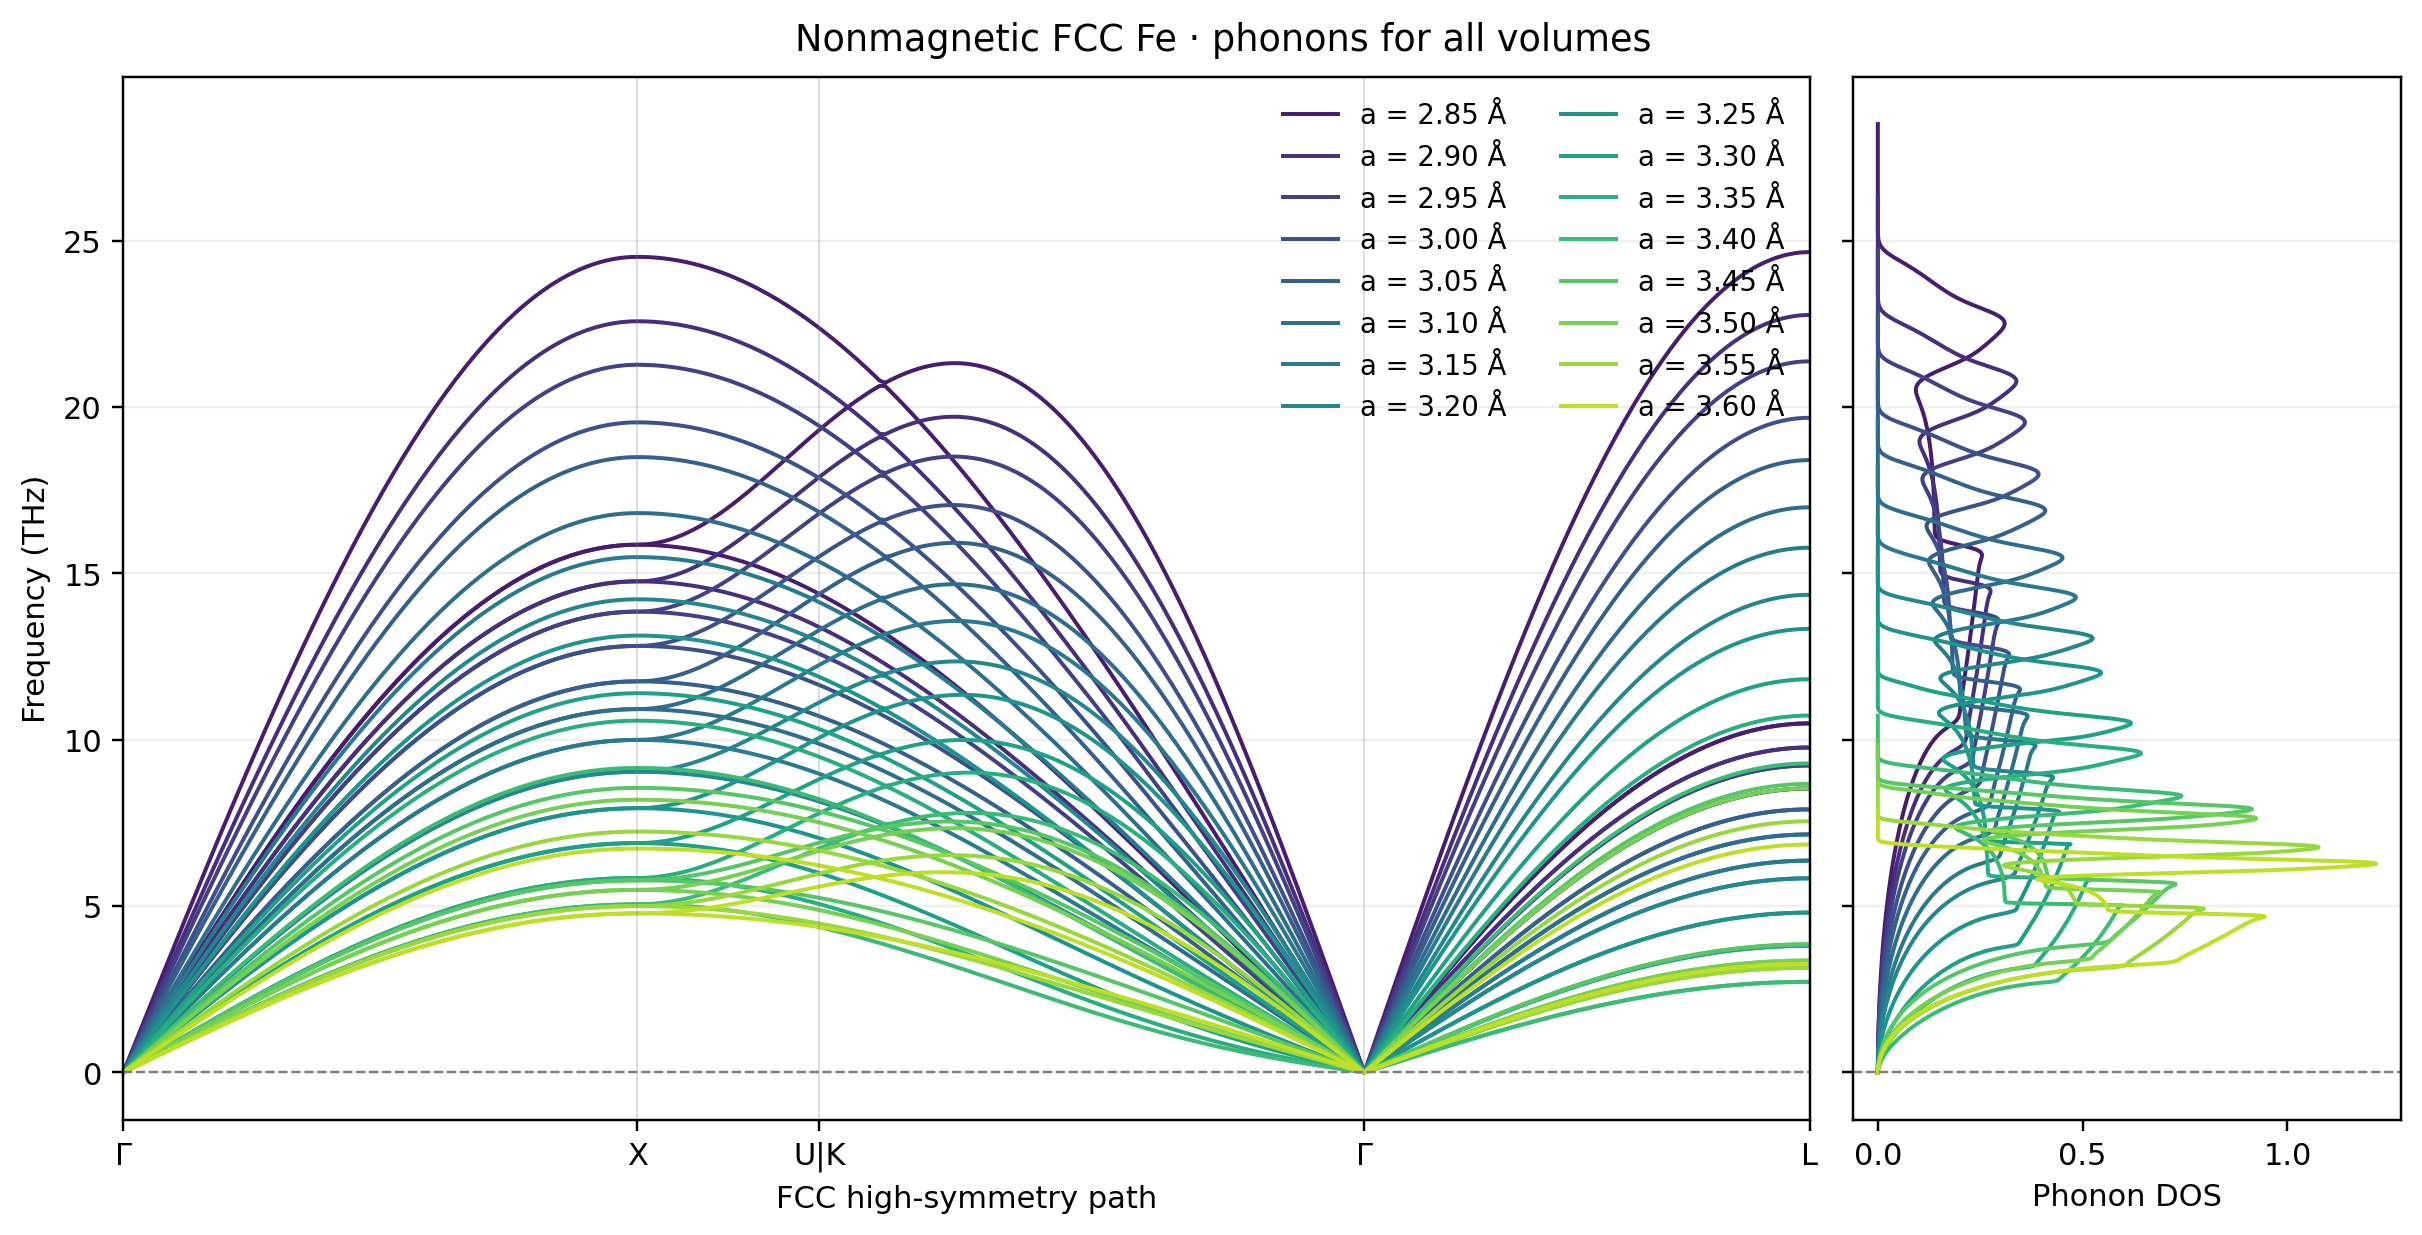

Volúmenes incluidos: 16
/Users/dajuarez4/Documents/Fe/dataset/fcc/non-mag/tdep_results_4000K/phonons_all_volumes.png


In [6]:
# Solo lectura y gráficas: no vuelve a ejecutar TDEP.
from pathlib import Path
import re
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Image

if "TEMPERATURE" not in globals():TEMPERATURE=4000
if "OUT" not in globals():
    base=Path.cwd()
    if not (base/f"tdep_results_{TEMPERATURE}K").is_dir():
        base=Path("/Users/dajuarez4/Documents/Fe/dataset/fcc/non-mag")
    OUT=base/f"tdep_results_{TEMPERATURE}K"

def read_overlay_ticks(path):
    text=path.read_text()
    if "THz" not in text:raise ValueError("Verificar unidades de frecuencia: "+str(path))
    pairs=re.findall(r'"([^"\n]+)"\s+([0-9.eE+-]+)',text)
    labels=[label for label,x in pairs]
    ticks=np.array([float(x) for label,x in pairs])
    if len(ticks)<2 or np.any(np.diff(ticks)<=0):raise ValueError("Ruta de simetría inválida: "+str(path))
    return labels,ticks

folders=sorted([p for p in (OUT/"calculations").glob("a_*")
                if p.is_dir() and re.fullmatch(r"a_[0-9.]+",p.name)],
               key=lambda p:float(p.name[2:]))
curves=[]
for folder in folders:
    required=[folder/"outfile.dispersion_relations",folder/"outfile.dispersion_relations.gnuplot"]
    if not all(p.exists() for p in required):
        print("Sin dispersión todavía:",folder.name);continue
    bands=np.loadtxt(required[0],ndmin=2)
    labels,ticks=read_overlay_ticks(required[1])
    if not np.isfinite(bands).all():raise ValueError("Frecuencias no finitas: "+folder.name)
    dos_path=folder/"outfile.phonon_dos"
    dos=np.loadtxt(dos_path,ndmin=2) if dos_path.exists() else None
    curves.append((folder,bands,labels,ticks,dos))
if not curves:raise RuntimeError("No hay dispersiones; ejecutar primero la celda TDEP.")

ref_labels,ref_ticks=curves[0][2:4]
fig,(ax,dx)=plt.subplots(1,2,figsize=(11,5.5),sharey=True,
                         gridspec_kw={"width_ratios":[4,1.3]},layout="constrained")
colors=plt.get_cmap("viridis")(np.linspace(.08,.9,len(curves)))
for color,(folder,bands,labels,ticks,dos) in zip(colors,curves):
    if labels!=ref_labels:raise ValueError("Las rutas de simetría no coinciden: "+folder.name)
    # Las distancias recíprocas dependen de a; alinear cada tramo de simetría.
    x=np.interp(bands[:,0],ticks,ref_ticks)
    a=float(folder.name[2:])
    for branch in range(1,bands.shape[1]):
        ax.plot(x,bands[:,branch],color=color,lw=1.3,
                label=f"a = {a:.2f} Å" if branch==1 else None)
    if dos is not None:dx.plot(dos[:,1],dos[:,0],color=color,lw=1.3)
for tick in ref_ticks:ax.axvline(tick,color="gray",lw=.5,alpha=.35)
ax.set_xticks(ref_ticks,ref_labels)
ax.set_xlim(ref_ticks[0],ref_ticks[-1])
ax.set_ylabel("Frequency (THz)")
ax.set_xlabel("FCC high-symmetry path")
ax.legend(frameon=False,fontsize=9,ncol=2)
dx.set_xlabel("Phonon DOS")
for panel in (ax,dx):
    panel.axhline(0,color="gray",lw=.8,ls="--")
    panel.grid(axis="y",alpha=.18)
fig.suptitle("Nonmagnetic FCC Fe · phonons for all volumes")
for ext in ("png","pdf"):
    fig.savefig(OUT/("phonons_all_volumes."+ext),dpi=220,bbox_inches="tight")
plt.close(fig)
display(Image(filename=str(OUT/"phonons_all_volumes.png"),width=1100))
print("Volúmenes incluidos:",len(curves))
print(OUT/"phonons_all_volumes.png")
